# Translator English to Spanish

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from torchvision.transforms import ToTensor
from sklearn.model_selection import train_test_split
from dataset import Dataset
from dataset import Tokenizer
from transformer import Transformer
import os

dataset_path = os.path.join("dataset","dataset_800k.json")

%reload_ext autoreload
%autoreload 2

## Dataset Análisis

In [38]:
import pandas as pd
import numpy as np
import json

with open(dataset_path, 'r', encoding='utf-8') as f:
    data = json.load(f)
    # Convertir a DataFrame
    df = pd.DataFrame(data)

df.head(5)


,en,es
0,"We know, for example, that the levels of pollu...","Sabemos que, por ejemplo, en la Unión Europea ..."
1,Frost is a kind of crystallized dew that forms...,La escarcha es una especie de rocío cristaliza...
2,"Finally, let me again express my appreciation ...","Por último, permítanme expresar de nuevo mi ag..."
3,It now has an opportunity to make up for that.,Ahora tiene la ocasión de lavar esa mala imagen.
4,My view is that we will only be able to do thi...,Mi opinión es que solamente podemos hacerlo co...


In [39]:
print(f"Tamaño dataset inicial: {len(df)}")

Tamaño dataset inicial: 800000


Es necesario realizar una limpieza del dataset. Eliminaremos pares de frase que no tengan traducción.

In [40]:
#Nulos, vacíos, idénticos y longitud mínima

df_clean = df.dropna().copy()
df_clean = df_clean[(df_clean['en'].str.strip() != "") & (df_clean['es'].str.strip() != "")] #vacios
df_clean = df_clean[df_clean['en'] != df_clean['es']] #eliminamos identicos
df_clean = df_clean[(df_clean['en'].str.split().str.len() >= 3) & (df_clean['es'].str.split().str.len() >= 3)]


long_en = df_clean['en'].str.split().str.len()
long_es = df_clean['es'].str.split().str.len()
ratio = long_es / long_en

#Filtrado final por ratio (0.5 < ratio < 2.0)
mask = (ratio > 0.5) & (ratio < 2.0)
df_clean = df_clean[(ratio > 0.5) & (ratio < 2.0)]


metrics = pd.DataFrame({
    'long_en': long_en[mask],
    'long_es': long_es[mask],
    'ratio': ratio[mask]
})

print(f"Pares de frases eliminados: {len(df) - len(df_clean)}")


Pares de frases eliminados: 21064


EL primer análisis será las longitudes de las frases:

In [41]:
percentiles = [.25, .5, .75, .9, .95]
datos = metrics[[ 'long_en', 'long_es','ratio']].describe(percentiles=percentiles)

pd.options.display.float_format = '{:.2f}'.format
datos

,long_en,long_es,ratio
count,778936.00,778936.00,778936.00
mean,23.18,24.28,1.05
std,15.30,16.44,0.19
min,3.00,3.00,0.51
25%,12.00,12.00,0.93
50%,20.00,21.00,1.03
75%,31.00,33.00,1.16
90%,43.00,46.00,1.29
95%,52.00,55.00,1.38
max,668.00,658.00,1.99


También nos interesa saber la cantidad de palabras únicas que hay en cada idioma:

In [42]:
def lexico(df):

    #aplica a cada frase una separacion por caracteres sin tener en cuenta signos de puntuacion, interrogacion y exclamacion
    #\w+ es una ER
    vocab = df.str.lower().str.findall(r'\w+') ##tipo panda.Series()
    vocab = vocab.explode() #convierte cada elemento en una fila pero no tiene en cuenta repetidos
    vocab = vocab.value_counts()
    
    return vocab.to_dict()


en_vocab = lexico(df['en'])
es_vocab = lexico(df['es'])

vocab = pd.DataFrame()
vocab['Palabras Unicas Ingles'] = [len(en_vocab)]
vocab['Palabras Unicas Español'] = [len(es_vocab)]
vocab
    

,Palabras Unicas Ingles,Palabras Unicas Español
0,63982,112966


Y una vez tenemos el diccionario de palabras únicas es interesante ver cuales son las palabras que más se repiten en cada idioma

In [43]:
from collections import Counter
import re

n = 10

top_en = Counter(en_vocab).most_common(n)
top_es = Counter(es_vocab).most_common(n)
    
# Creamos el DataFrame
tabla = pd.DataFrame({
    'Rank': range(1, n + 1),
    'Word (EN)': [word for word, count in top_en],
    'Freq (EN)': [f"{count:,}" for word, count in top_en],
    'Word (ES)': [word for word, count in top_es],
    'Freq (ES)': [f"{count:,}" for word, count in top_es]
    })

tabla

,Rank,Word (EN),Freq (EN),Word (ES),Freq (ES)
0,1,the,"1,370,538",de,"1,292,839"
1,2,of,"644,543",la,"885,529"
2,3,to,"613,509",que,"692,851"
3,4,and,"509,981",en,"563,486"
4,5,in,"429,721",el,"510,773"
5,6,that,"329,693",y,"479,774"
6,7,a,"314,072",a,"423,137"
7,8,is,"310,044",los,"388,067"
8,9,i,"222,381",las,"265,128"
9,10,for,"209,695",se,"214,408"


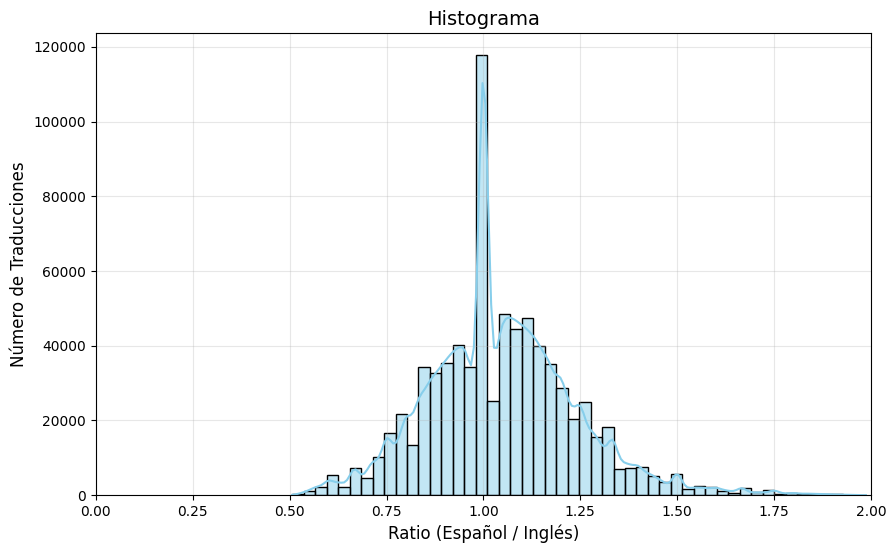

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_ratios(df):
    plt.figure(figsize=(10, 6))
    
    # Creamos el histograma con una línea de densidad (KDE)
    sns.histplot(df['ratio'], bins=50, kde=True, color='skyblue')
    
    # Dibujamos una línea en la media (1.05)
    #plt.axvline(df['ratio'].mean(), color='red', linestyle='--', label=f"Media: {df['ratio'].mean():.2f}")
    
    # Configuración de estética
    plt.title('Histograma', fontsize=14)
    plt.xlabel('Ratio (Español / Inglés)', fontsize=12)
    plt.ylabel('Número de Traducciones', fontsize=12)
    plt.xlim(0, 2) # Limitamos la vista para que se vea bien el grueso de los datos
    plt.grid(alpha=0.3)
    
    plt.savefig('distribucion_ratios.png')
    plt.show()

# Para ejecutarlo:
graficar_ratios(metrics)

## Vocabulario y Tokens


Una vez tenemos el dataset, necesitamos tokenizar la entrada pues es lo que el modelo acepta como entrada.


Inicialmente, se pensó usar el vocabulario de GPT2 con 52.000 tokens, pero dicho vocabulario se entrena solo con frases en inglés y hace que al modelo le cueste aprender.

Lo mejor es crear nuestro propio vocabulario mediante el algoritmo Byte Pair Encoding.

Crearemos un vocabulario formado por 15.000 tokens

In [1]:
import json
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

vocabulario = "vocabulario.json"

# 2. Función generadora para pasarle el texto al entrenador sin saturar la RAM
def generador_de_textos(ruta_json):
    with open(ruta_json, 'r', encoding='utf-8') as f:
        datos = json.load(f)
        for par in datos:
            # Mandamos a entrenar tanto la frase en inglés como en español
            yield par['en']
            yield par['es']

# 3. Inicializamos el Tokenizador BPE
# Todo lo que no conozca lo marcará como <UNK> 
tokenizer = Tokenizer(BPE(unk_token="<UNK>"))

tokenizer.pre_tokenizer = Whitespace() # separar por espacios en blanco antes de aplicar el BPE


# 15,000 tamaño vocab 
entrenador = BpeTrainer(
    vocab_size=15000, 
    special_tokens=["<PAD>", "<START>", "<END>", "<UNK>"]
)


print("Entrenando el tokenizador...")
# 5. ¡A entrenar! Le pasamos el generador
tokenizer.train_from_iterator(generador_de_textos(dataset_path), trainer=entrenador)

# 6. Guardamos el tokenizador entrenado en un archivo para usarlo siempre
tokenizer.save(vocabulario)

print(f"Tamaño final del vocabulario: {tokenizer.get_vocab_size()} tokens.")

Entrenando el tokenizador...


NameError: name 'dataset_path' is not defined

## Pruebas

Una vez entrenado el modelo, realizamos pruebas y vemos el comportamiento del modelo

In [3]:
vocab_path = "vocabulario/vocabulario_32k.json"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
tokenizer = Tokenizer(vocab_path)
transformer = Transformer(vocab_size=len(tokenizer),pad_id= tokenizer.pad_id()).to(device=device)

#Cargamos el modelo 
weights  = torch.load(os.path.join("resultados","14_val_1.0604.pth"), map_location=device, weights_only=True)
transformer.load_state_dict(weights,strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['encoder_blocks.0.attention_heads.block_attention.0.tril', 'encoder_blocks.0.attention_heads.block_attention.1.tril', 'encoder_blocks.0.attention_heads.block_attention.2.tril', 'encoder_blocks.0.attention_heads.block_attention.3.tril', 'encoder_blocks.0.attention_heads.block_attention.4.tril', 'encoder_blocks.0.attention_heads.block_attention.5.tril', 'encoder_blocks.0.attention_heads.block_attention.6.tril', 'encoder_blocks.0.attention_heads.block_attention.7.tril', 'encoder_blocks.1.attention_heads.block_attention.0.tril', 'encoder_blocks.1.attention_heads.block_attention.1.tril', 'encoder_blocks.1.attention_heads.block_attention.2.tril', 'encoder_blocks.1.attention_heads.block_attention.3.tril', 'encoder_blocks.1.attention_heads.block_attention.4.tril', 'encoder_blocks.1.attention_heads.block_attention.5.tril', 'encoder_blocks.1.attention_heads.block_attention.6.tril', 'encoder_blocks.1.attention_heads.block_attention.7.tril', 'enc

In [7]:
print(sum(p.numel() for p in transformer.parameters())/1e6, 'M parameters')

93.351168 M parameters


In [ ]:
def print_result(test):

    transformer.eval() # Aseguramos modo evaluación

    print("=" * 100)
    print(f"{'RESULTADOS DE LA TRADUCCIÓN':^100}")
    print("=" * 100)

    for i, frase in enumerate(test):
        # Tokenización y predicción
        x_tokens = torch.tensor(np.array([tokenizer.encode(frase, pad=False)])).to('cuda')
        y_tokens = torch.tensor(np.array([[tokenizer.star_of_text_id()]])).to('cuda')
        
        output = transformer.predict(
            x_tokens, 
            y_tokens,
            end_token_id=tokenizer.end_of_text_id(),
            device='cuda'
        )
        
        # Decodificación de la traducción
        traduccion = tokenizer.decoder(output[0])
        
        # Formato de salida: Inglés arriba, Español abajo
        print(f"[{i+1}] EN: {frase}")
        print(f"    ES: {traduccion}")
        print("-" * 100) # Línea divisoria después de cada traducción


test_1 = [
    "I'm so happy to see you!",                       
    "Is Chae Yoon's coordinator in here?",           
    "What a wonderful surprise!",                    
    "Where are you going right now?",                
    "Stop talking and listen to me!",                
    "Do you want to eat kimchee with me?",            
    "I can't believe it's finally working!",          
    "How much does this book cost?"
]


print_result(test_1)


                                    RESULTADOS DE LA TRADUCCIÓN                                     
[1] EN: I'm so happy to see you!
    ES: ¡Me alegra mucho veros!
----------------------------------------------------------------------------------------------------
[2] EN: Is Chae Yoon's coordinator in here?
    ES: ¿El coordinador de Jesaque escantendtivo?
----------------------------------------------------------------------------------------------------
[3] EN: What a wonderful surprise!
    ES: ¡Qué agradable sorpresa!
----------------------------------------------------------------------------------------------------
[4] EN: Where are you going right now?
    ES: ¿Adónde marchás enseguida?
----------------------------------------------------------------------------------------------------
[5] EN: Stop talking and listen to me!
    ES: Me t amable de hablar y escistarme.
----------------------------------------------------------------------------------------------------
[6] EN: Do

In [20]:
# BLOQUE 2: Negocios y Entorno Profesional
test_2 = [
    "Please send me the updated report by tomorrow morning.",
    "We need to schedule a follow-up meeting with the stakeholders.",
    "The quarterly results exceeded all our initial expectations.",
    "Could you please forward that email to the entire department?",
    "I am writing to confirm our appointment for next Tuesday.",
    "The budget for this project has not been approved yet.",
    "Who is responsible for the marketing strategy this year?",
    "We should focus on improving customer satisfaction levels."
]
print_result(test_2)

                                    RESULTADOS DE LA TRADUCCIÓN                                     
[1] EN: Please send me the updated report by tomorrow morning.
    ES: Por favor envíceme el actual informe de mañana por la mañana.
----------------------------------------------------------------------------------------------------
[2] EN: We need to schedule a follow-up meeting with the stakeholders.
    ES: Tenemos que encargarnos de la actuación con las de los interesados.
----------------------------------------------------------------------------------------------------
[3] EN: The quarterly results exceeded all our initial expectations.
    ES: El 25% ejercía todas nuestras expectativas iniciales.
----------------------------------------------------------------------------------------------------
[4] EN: Could you please forward that email to the entire department?
    ES: ¿Podés enviar ese correo a todo el departamento?
----------------------------------------------------------

In [21]:
test_3 = [
    "Large language models require significant computational resources.",
    "The neural network architecture consists of several hidden layers.",
    "Data preprocessing is a crucial step in any machine learning pipeline.",
    "How does the attention mechanism improve translation quality?",
    "The algorithm optimized the weights to minimize the loss function.",
    "Is it possible to run this model on a single GPU?",
    "Quantum computing could revolutionize the field of cryptography.",
    "The dataset contains thousands of labeled images for training."
]
print_result(test_3)

                                    RESULTADOS DE LA TRADUCCIÓN                                     
[1] EN: Large language models require significant computational resources.
    ES: Un famoso campo requiere recursos de compásper.
----------------------------------------------------------------------------------------------------
[2] EN: The neural network architecture consists of several hidden layers.
    ES: La dinámica de Red Trans reside de varios servios ocultos.
----------------------------------------------------------------------------------------------------
[3] EN: Data preprocessing is a crucial step in any machine learning pipeline.
    ES: El procesado de notiso es un paso crucial en cualquier curso de aprendizaje flexible.
----------------------------------------------------------------------------------------------------
[4] EN: How does the attention mechanism improve translation quality?
    ES: ¿Cómo mejora el mecanismo de atención de traducción?
-------------------

In [22]:
test_4 = [
    "The old lighthouse stood firmly against the crashing waves of the sea.",
    "Despite the heavy rain, the marathon runners refused to give up.",
    "Hidden deep within the forest, they found a path long forgotten by time.",
    "Technology has changed the way we communicate with each other forever.",
    "If I had known you were coming, I would have baked a delicious cake.",
    "The stars were shining brightly on that cold winter night in the mountains.",
    "Learning a new language opens up a world of endless opportunities.",
    "She realized that the most important things in life aren't objects."
]
print_result(test_4)

                                    RESULTADOS DE LA TRADUCCIÓN                                     
[1] EN: The old lighthouse stood firmly against the crashing waves of the sea.
    ES: Los cubiertos de cubierta antiguos se disiparon decididamente contra las enubllas del mar.
----------------------------------------------------------------------------------------------------
[2] EN: Despite the heavy rain, the marathon runners refused to give up.
    ES: Añoradoras de los tormentos pesados se negaron a ceder a lo grande.
----------------------------------------------------------------------------------------------------
[3] EN: Hidden deep within the forest, they found a path long forgotten by time.
    ES: Haga la profunda profunda del forestal, se buscaron un largo camino olvidado antes de tiempo.
----------------------------------------------------------------------------------------------------
[4] EN: Technology has changed the way we communicate with each other forever.
    ES: